### Set up

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import gc
from functions import compute_grand_tfr

In [2]:
base_dir = '/home/p2894/mne_eeg_workshop/ds006777'
derivatives_dir = os.path.join(base_dir, 'derivatives')
results_dir = os.path.join(base_dir, 'results')

if not os.path.exists(results_dir):
    os.makedirs(results_dir)
    print(f"Has successfully created: {results_dir}")
else:
    print("Folder `results` exists. No need to create.")

log_file_path = os.path.join(results_dir, 'TFR_topomap_log.txt')
mne.set_log_file(log_file_path, overwrite=True)

Folder `results` exists. No need to create.


### Parameters for computing TFR

In [3]:
freqs = np.logspace(*np.log10([1, 50]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency

### Topographic maps for AV across five frequency bands (TD)

In [4]:
subject_paths = glob.glob(os.path.join(derivatives_dir, 'sub-10*'))
subject_ids = sorted([os.path.basename(p) for p in subject_paths if os.path.isdir(p)])
#subject_ids = ['sub-10025']
condition = 'AV'
picks = ['eeg']

#### Compute TFR across all channels

**NOTE:** It will take some time (about 6.5 min).

For some subjects whose files do not exist, it is because their data were not permitted to be processed during preprocessing stage due to too many noisy signals or poor behavioral responses. So these subjects would not have a epoch file in the repective subject folder.

In [5]:
grand_power_AV_TD, all_power_AV_TD = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-10129 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10129/sub-10129_eeg-epo.fif"
sub-10170 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10170/sub-10170_eeg-epo.fif"
sub-10182 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10182/sub-10182_eeg-epo.fif"
sub-10258 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10258/sub-10258_eeg-epo.fif"
sub-10314 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10314/sub-10314_eeg-epo.fif"
sub-10508 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10508/sub-10508_eeg-epo.fif"
sub-10764 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10764/sub-10764_eeg-epo.fif"
sub-10769 failed to be proc

#### Check TFR data

In [6]:
for i, tfr in enumerate(all_power_AV_TD):
    print(f"Index {i} | Shape: {tfr.data.shape} | Time points: {len(tfr.times)}")

Index 0 | Shape: (64, 100, 141) | Time points: 141
Index 1 | Shape: (64, 100, 141) | Time points: 141
Index 2 | Shape: (64, 100, 141) | Time points: 141
Index 3 | Shape: (64, 100, 141) | Time points: 141
Index 4 | Shape: (64, 100, 141) | Time points: 141
Index 5 | Shape: (64, 100, 141) | Time points: 141
Index 6 | Shape: (64, 100, 141) | Time points: 141
Index 7 | Shape: (64, 100, 141) | Time points: 141
Index 8 | Shape: (64, 100, 141) | Time points: 141
Index 9 | Shape: (64, 100, 141) | Time points: 141
Index 10 | Shape: (64, 100, 141) | Time points: 141
Index 11 | Shape: (64, 100, 141) | Time points: 141
Index 12 | Shape: (64, 100, 141) | Time points: 141
Index 13 | Shape: (64, 100, 141) | Time points: 141
Index 14 | Shape: (64, 100, 141) | Time points: 141
Index 15 | Shape: (64, 100, 141) | Time points: 141
Index 16 | Shape: (64, 100, 141) | Time points: 141
Index 17 | Shape: (64, 100, 141) | Time points: 141
Index 18 | Shape: (64, 100, 141) | Time points: 141
Index 19 | Shape: (64,

#### Save grand TFR file to `results` folder

In [ ]:
tfr_file_path = os.path.join(results_dir, 'grand_AV_TD-tfr.h5')
grand_power_AV_TD.save(tfr_file_path, overwrite=True)

#### Visualization

Text(0.5, 0.95, 'Topographic maps for AV Conditions in TD')

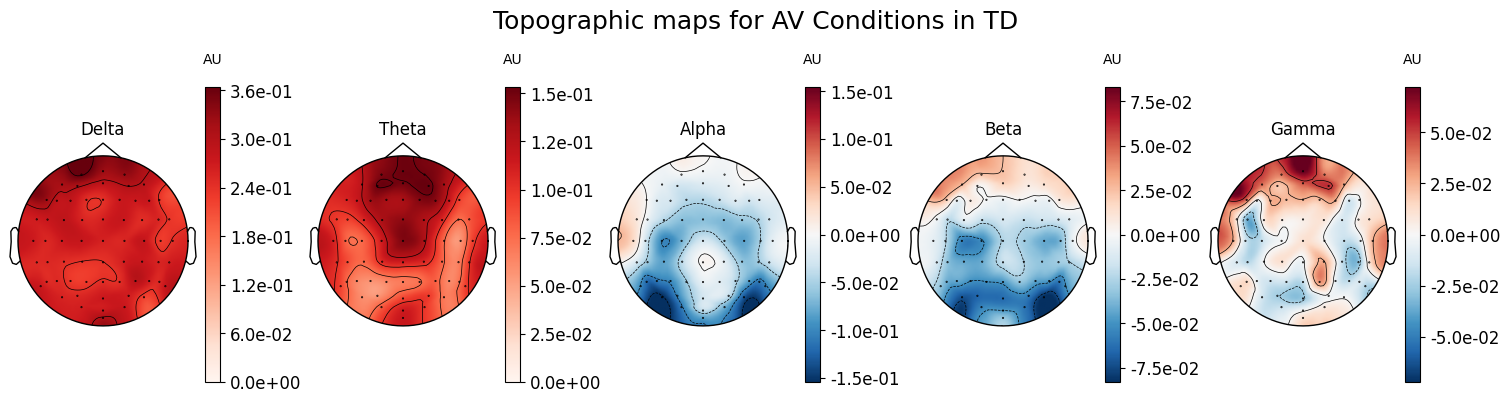

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), layout="constrained")

topomap_kw = dict(
    ch_type="eeg",
    tmin=0, 
    tmax=0.9, 
    baseline=(-0.2, 0), 
    mode="logratio",
    #vlim=(-0.3, 0.3), 
    show=False
)

plot_dict = dict(Delta=dict(fmin=1, fmax=4), 
                 Theta=dict(fmin=4, fmax=8), 
                 Alpha=dict(fmin=8, fmax=12), 
                 Beta=dict(fmin=12, fmax=30), 
                 Gamma=dict(fmin=30, fmax=50))

for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    grand_power_AV_TD.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)

fig.suptitle('Topographic maps for AV Conditions in TD', fontsize=18, y=0.95)

### Topographic maps for AV across five frequency bands (ASC)

In [9]:
subject_paths = glob.glob(os.path.join(derivatives_dir, 'sub-11*'))
subject_ids = sorted([os.path.basename(p) for p in subject_paths if os.path.isdir(p)])
condition = 'AV'
picks = ['eeg']

#### Compute TFR across all channels

**NOTE:** It will take some time (about 11 min).

For some subjects whose files do not exist, it is because their data were not permitted to be processed during preprocessing stage due to too many noisy signals or poor behavioral responses. So these subjects would not have a epoch file in the repective subject folder.

In [10]:
grand_power_AV_ASC, all_power_AV_ASC = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-11057 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11057/sub-11057_eeg-epo.fif"
sub-11152 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11152/sub-11152_eeg-epo.fif"
sub-11161 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11161/sub-11161_eeg-epo.fif"
sub-11204 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11204/sub-11204_eeg-epo.fif"
sub-11243 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11243/sub-11243_eeg-epo.fif"
sub-11335 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11335/sub-11335_eeg-epo.fif"
sub-11547 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11547/sub-11547_eeg-epo.fif"
sub-11548 failed to be proc

#### Check TFR data

In [11]:
for i, tfr in enumerate(all_power_AV_ASC):
    print(f"Index {i} | Shape: {tfr.data.shape} | Time points: {len(tfr.times)}")

Index 0 | Shape: (64, 100, 141) | Time points: 141
Index 1 | Shape: (64, 100, 141) | Time points: 141
Index 2 | Shape: (64, 100, 141) | Time points: 141
Index 3 | Shape: (64, 100, 141) | Time points: 141
Index 4 | Shape: (64, 100, 141) | Time points: 141
Index 5 | Shape: (64, 100, 141) | Time points: 141
Index 6 | Shape: (64, 100, 141) | Time points: 141
Index 7 | Shape: (64, 100, 141) | Time points: 141
Index 8 | Shape: (64, 100, 141) | Time points: 141
Index 9 | Shape: (64, 100, 141) | Time points: 141
Index 10 | Shape: (64, 100, 141) | Time points: 141
Index 11 | Shape: (64, 100, 141) | Time points: 141
Index 12 | Shape: (64, 100, 141) | Time points: 141
Index 13 | Shape: (64, 100, 141) | Time points: 141
Index 14 | Shape: (64, 100, 141) | Time points: 141
Index 15 | Shape: (64, 100, 141) | Time points: 141
Index 16 | Shape: (64, 100, 141) | Time points: 141
Index 17 | Shape: (64, 100, 141) | Time points: 141
Index 18 | Shape: (64, 100, 141) | Time points: 141
Index 19 | Shape: (64,

#### Save grand TFR file to `results` folder

In [12]:
tfr_file_path = os.path.join(results_dir, 'grand_AV_ASC-tfr.h5')
grand_power_AV_ASC.save(tfr_file_path, overwrite=True)

#### Visualization

Text(0.5, 0.95, 'Topographic maps for AV Conditions in ASC')

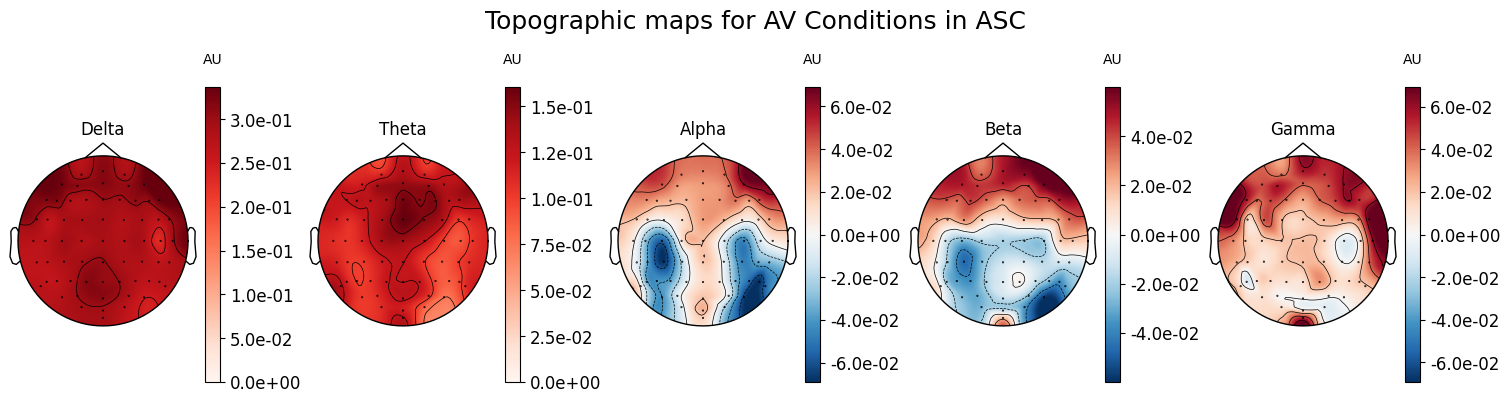

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), layout="constrained")

topomap_kw = dict(
    ch_type="eeg",
    tmin=0, 
    tmax=0.9, 
    baseline=(-0.2, 0), 
    mode="logratio",
    #vlim=(-0.3, 0.3), 
    show=False
)

plot_dict = dict(Delta=dict(fmin=1, fmax=4), 
                 Theta=dict(fmin=4, fmax=8), 
                 Alpha=dict(fmin=8, fmax=12), 
                 Beta=dict(fmin=12, fmax=30), 
                 Gamma=dict(fmin=30, fmax=50))

for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    grand_power_AV_ASC.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)

fig.suptitle('Topographic maps for AV Conditions in ASC', fontsize=18, y=0.95)

### TFR across conditions in TD

In [14]:
subject_paths = glob.glob(os.path.join(derivatives_dir, 'sub-10*'))
subject_ids = sorted([os.path.basename(p) for p in subject_paths if os.path.isdir(p)])
#subject_ids = ['sub-10025', 'sub-10036', 'sub-10177']
picks = ['eeg']

**NOTE:** It will take some time (about 5.5 min per cell when running `compute_grand_tfr`).

For some subjects whose files do not exist, it is because their data were not permitted to be processed during preprocessing stage due to too many noisy signals or poor behavioral responses. So these subjects would not have a epoch file in the repective subject folder.

In [15]:
condition = 'A'
grand_power_A_TD, all_power_A_TD = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-10129 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10129/sub-10129_eeg-epo.fif"
sub-10170 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10170/sub-10170_eeg-epo.fif"
sub-10182 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10182/sub-10182_eeg-epo.fif"
sub-10258 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10258/sub-10258_eeg-epo.fif"
sub-10314 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10314/sub-10314_eeg-epo.fif"
sub-10508 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10508/sub-10508_eeg-epo.fif"
sub-10764 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10764/sub-10764_eeg-epo.fif"
sub-10769 failed to be proc

In [16]:
tfr_file_path = os.path.join(results_dir, 'grand_A_TD-tfr.h5')
grand_power_A_TD.save(tfr_file_path, overwrite=True)

In [17]:
condition = 'V'
grand_power_V_TD, all_power_V_TD = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-10129 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10129/sub-10129_eeg-epo.fif"
sub-10170 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10170/sub-10170_eeg-epo.fif"
sub-10182 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10182/sub-10182_eeg-epo.fif"
sub-10258 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10258/sub-10258_eeg-epo.fif"
sub-10314 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10314/sub-10314_eeg-epo.fif"
sub-10508 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10508/sub-10508_eeg-epo.fif"
sub-10764 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-10764/sub-10764_eeg-epo.fif"
sub-10769 failed to be proc

In [18]:
tfr_file_path = os.path.join(results_dir, 'grand_V_TD-tfr.h5')
grand_power_V_TD.save(tfr_file_path, overwrite=True)

### TFR across conditions in ASC

In [19]:
subject_paths = glob.glob(os.path.join(derivatives_dir, 'sub-11*'))
subject_ids = sorted([os.path.basename(p) for p in subject_paths if os.path.isdir(p)])
picks = ['eeg']

**NOTE:** It will take some time (about 10 min per cell when running `compute_grand_tfr`).

For some subjects whose files do not exist, it is because their data were not permitted to be processed during preprocessing stage due to too many noisy signals or poor behavioral responses. So these subjects would not have a epoch file in the repective subject folder.

In [20]:
condition = 'A'
grand_power_A_ASC, all_power_A_ASC = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-11057 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11057/sub-11057_eeg-epo.fif"
sub-11152 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11152/sub-11152_eeg-epo.fif"
sub-11161 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11161/sub-11161_eeg-epo.fif"
sub-11204 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11204/sub-11204_eeg-epo.fif"
sub-11243 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11243/sub-11243_eeg-epo.fif"
sub-11335 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11335/sub-11335_eeg-epo.fif"
sub-11547 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11547/sub-11547_eeg-epo.fif"
sub-11548 failed to be proc

In [21]:
tfr_file_path = os.path.join(results_dir, 'grand_A_ASC-tfr.h5')
grand_power_A_ASC.save(tfr_file_path, overwrite=True)

In [22]:
condition = 'V'
grand_power_V_ASC, all_power_V_ASC = compute_grand_tfr(derivatives_dir,subject_ids,freqs,n_cycles,condition,picks)

sub-11057 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11057/sub-11057_eeg-epo.fif"
sub-11152 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11152/sub-11152_eeg-epo.fif"
sub-11161 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11161/sub-11161_eeg-epo.fif"
sub-11204 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11204/sub-11204_eeg-epo.fif"
sub-11243 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11243/sub-11243_eeg-epo.fif"
sub-11335 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11335/sub-11335_eeg-epo.fif"
sub-11547 failed to be processed: File does not exist: "/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-11547/sub-11547_eeg-epo.fif"
sub-11548 failed to be proc

In [23]:
tfr_file_path = os.path.join(results_dir, 'grand_V_ASC-tfr.h5')
grand_power_V_ASC.save(tfr_file_path, overwrite=True)

### Visualization of TFR across experimental conditions for each group

In [4]:
grand_power_AV_ASC = mne.time_frequency.read_tfrs(os.path.join(results_dir, 'grand_AV_ASC-tfr.h5'))
grand_power_A_ASC = mne.time_frequency.read_tfrs(os.path.join(results_dir, 'grand_A_ASC-tfr.h5'))
grand_power_V_ASC = mne.time_frequency.read_tfrs(os.path.join(results_dir, 'grand_V_ASC-tfr.h5'))
grand_power_AV_TD = mne.time_frequency.read_tfrs(os.path.join(results_dir, 'grand_AV_TD-tfr.h5'))
grand_power_A_TD = mne.time_frequency.read_tfrs(os.path.join(results_dir, 'grand_A_TD-tfr.h5'))
grand_power_V_TD = mne.time_frequency.read_tfrs(os.path.join(results_dir, 'grand_V_TD-tfr.h5'))

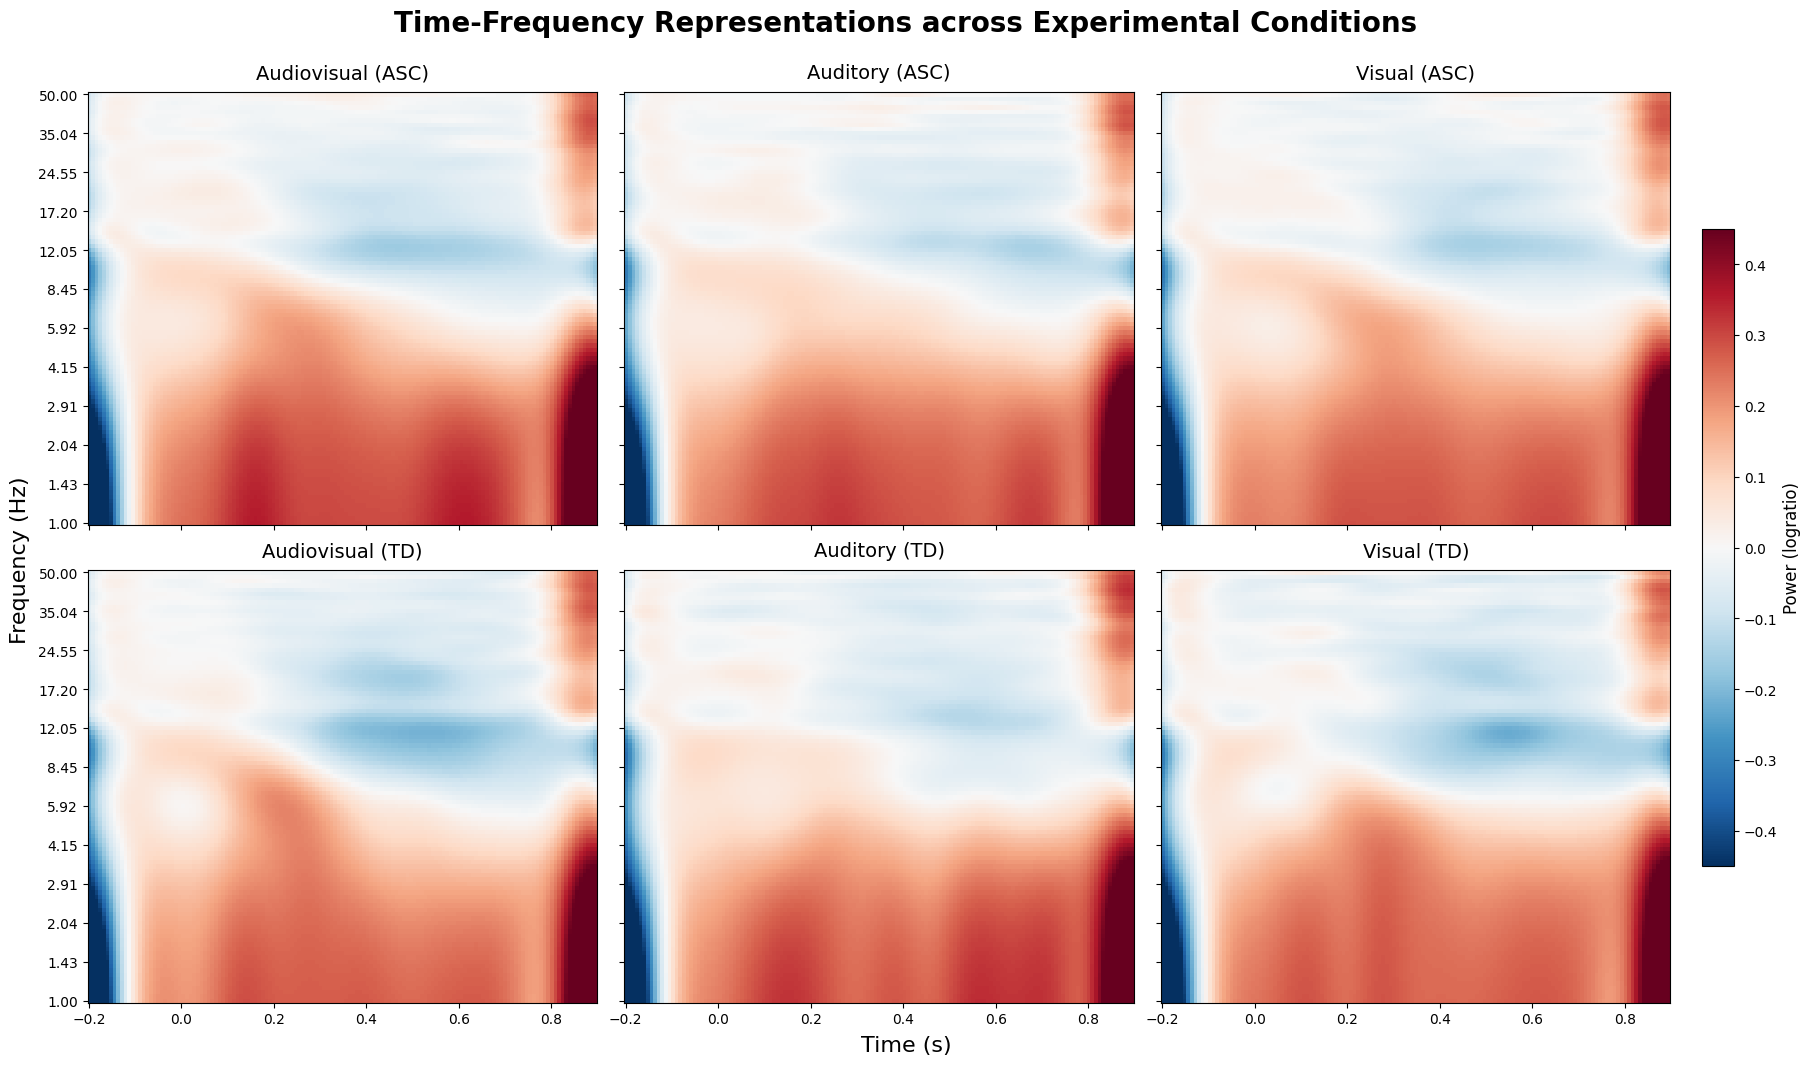

In [62]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']
fig, axes = plt.subplots(2, 3, figsize=(18, 10), layout="constrained")

# 保持你目前的資料順序
tfr_list = [
    grand_power_AV_ASC, grand_power_A_ASC, grand_power_V_ASC, 
    grand_power_AV_TD, grand_power_A_TD, grand_power_V_TD
]
titles = [
    'Audiovisual (ASC)', 'Auditory (ASC)', 'Visual (ASC)', 
    'Audiovisual (TD)', 'Auditory (TD)', 'Visual (TD)'
]

vmin, vmax = -0.45, 0.45
im = None 

# 1. 依序將 TFR 畫進對應的子圖
for i, (tfr, title) in enumerate(zip(tfr_list, titles)):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    tfr.plot(
        picks=roi_channels, 
        baseline=(-0.2, 0), 
        mode="logratio", 
        combine='mean', 
        title="",           # 保持空字串，避免 MNE 內建雜亂後綴
        vlim=(vmin, vmax), 
        axes=ax, 
        colorbar=False,     # 禁用個別 colorbar
        show=False
    )
    
    # 手動設定乾淨的子圖標題
    ax.set_title(title, fontsize=14, pad=10)
    
    # 先把「所有」子圖的 X、Y 軸標籤與文字全部清空（後面再手動補特定的）
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelbottom=False, labelleft=False)

    # 抓取 QuadMesh 物件做全域 colorbar
    if im is None:
        im = ax.collections[0] if ax.collections else ax.images[0]

# 🌟 2. 關鍵：手動指定「最左邊」和「最下面」的子圖顯示標籤與刻度
# 讓最左邊的兩張圖 (第一列第一張、第二列第一張) 顯示 Frequency 刻度與標籤
for ax in [axes[0, 0], axes[1, 0]]:
    #ax.set_ylabel('Frequency (Hz)', fontsize=12)
    ax.tick_params(labelleft=True)

# 讓最下面的三張圖 (第二列的所有圖) 顯示 Time 刻度與標籤
for ax in axes[1, :]:
    #ax.set_xlabel('Time (s)', fontsize=12)
    ax.tick_params(labelbottom=True)

# 3. 建立全域大標題
fig.supylabel('Frequency (Hz)', fontsize=16)
fig.supxlabel('Time (s)', fontsize=16)
fig.suptitle('Time-Frequency Representations across Experimental Conditions', fontsize=20, fontweight='bold', y=1.05)

# 4. 建立全域唯一的共享 colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.7, pad=0.02)
cbar.set_label('Power (logratio)', fontsize=12)

plt.show()